# MLP (single frame)

Single-frame MLP baseline. Same 14-dim bbox feature as the LSTM but no temporal context. If the LSTM beats this, the gap is purely from temporal modeling. If the GNN beats both, the gap is from the richer skeleton input.

## Imports

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch

In [2]:
sys.path.insert(0, str(Path.cwd().parent))

In [3]:
from src.utils.config.config import Config
from src.classifier.common.constants import ACTION_NAMES, OBJECT_CAT_IDS
from src.classifier.common.trainer import BaseTrainer
from src.classifier.single_frame.dataset import HOIFrameDataset
from src.classifier.single_frame.model import SingleFrameClassifier

## Config

In [ ]:
SEED = 42

FEATURE_DIM = 4 + 4 + 2 + 1 + len(OBJECT_CAT_IDS)

config_loader = Config()
cfg = config_loader.load_config()
hp = cfg.mlp

dataset_root = cfg.project_root / cfg.paths.dataset / "CafeV1"
clips_root   = dataset_root / "Clips"
folds_path   = dataset_root / "folds.json"
runs_root    = cfg.project_root / "runs" / "single_frame"
runs_root.mkdir(parents=True, exist_ok=True)

print(f"device: {cfg.device}")
print(f"feature_dim: {FEATURE_DIM}")
print(f"hp: {hp}")

## Folds

In [5]:
def load_folds(path):
    with open(path) as f:
        return json.load(f)

def split(folds_data, val_fold):
    val = folds_data["folds"][val_fold]
    train = [c for i, f in enumerate(folds_data["folds"]) if i != val_fold for c in f]
    return train, val

def keys_to_dirs(keys, clips_root):
    return [clips_root / k.split("/")[0] / k.split("/")[1] for k in keys]

folds_data = load_folds(folds_path)
K = folds_data["k"]
print(f"loaded {K}-fold split, seed {folds_data['seed']}")

loaded 5-fold split, seed 42


## 5-fold training

In [ ]:
def run_fold(val_fold):
    torch.manual_seed(SEED + val_fold)
    np.random.seed(SEED + val_fold)

    train_keys, val_keys = split(folds_data, val_fold)

    train_set = HOIFrameDataset(
        clips_root, ACTION_NAMES,
        sample_every=hp.sample_every,
        clip_dirs=keys_to_dirs(train_keys, clips_root),
    )
    val_set = HOIFrameDataset(
        clips_root, ACTION_NAMES,
        sample_every=hp.sample_every,
        clip_dirs=keys_to_dirs(val_keys, clips_root),
    )

    model = SingleFrameClassifier(
        feature_dim=FEATURE_DIM,
        hidden_dim=hp.hidden,
        num_classes=len(ACTION_NAMES),
        dropout=hp.dropout,
    )

    trainer = BaseTrainer(
        model=model,
        dataset=train_set,
        class_names=ACTION_NAMES,
        lr=hp.lr, batch_size=hp.batch_size, epochs=hp.epochs,
        device=cfg.device,
        val_dataset=val_set,
    )

    save_path = runs_root / f"fold{val_fold}_best.pt"
    trainer.fit(save_path=str(save_path))

    trainer.model.load_state_dict(torch.load(save_path, map_location=cfg.device))
    return trainer.evaluate(), trainer.confusion_matrix()

In [7]:
fold_reports = []
fold_cms = []
for k in range(K):
    print(f"\n{'='*60}\nFold {k}\n{'='*60}")
    report, cm = run_fold(k)
    fold_reports.append(report)
    fold_cms.append(cm)
    print(f"\nFold {k} per class F1:")
    for name in ACTION_NAMES:
        print(f"  {name:15s} {report[name]['f1']:.3f}")


Fold 0
Built 8722 frame samples from 100 clips (skipped 0)
Built 2265 frame samples from 26 clips (skipped 0)
Epoch 1/50 | train_loss=0.6573 train_acc=0.8426 | val_loss=0.2581 val_acc=0.9439
  Saved best model to C:\Research\Prototype\skeleton-based-hoi-recognition\runs\single_frame\fold0_best.pt
Epoch 2/50 | train_loss=0.2215 train_acc=0.9539 | val_loss=0.2264 val_acc=0.9439
Epoch 3/50 | train_loss=0.1975 train_acc=0.9615 | val_loss=0.2194 val_acc=0.9611
  Saved best model to C:\Research\Prototype\skeleton-based-hoi-recognition\runs\single_frame\fold0_best.pt
Epoch 4/50 | train_loss=0.1889 train_acc=0.9676 | val_loss=0.2167 val_acc=0.9611
Epoch 5/50 | train_loss=0.1804 train_acc=0.9685 | val_loss=0.2085 val_acc=0.9611
Epoch 6/50 | train_loss=0.1822 train_acc=0.9686 | val_loss=0.2081 val_acc=0.9611
Epoch 7/50 | train_loss=0.1747 train_acc=0.9696 | val_loss=0.2111 val_acc=0.9611
Epoch 8/50 | train_loss=0.1752 train_acc=0.9690 | val_loss=0.2120 val_acc=0.9611
Epoch 9/50 | train_loss=0.1

## Summary

In [8]:
fold_cols = [f"fold_{k}" for k in range(K)]
rows = {fc: [rep[name]["f1"] for name in ACTION_NAMES]
        for fc, rep in zip(fold_cols, fold_reports)}

df = pd.DataFrame(rows, index=ACTION_NAMES)
df.loc["macro"] = df.mean(axis=0)
df["mean"] = df[fold_cols].mean(axis=1)
df["std"]  = df[fold_cols].std(axis=1)
df.round(3)

,fold_0,fold_1,fold_2,fold_3,fold_4,mean,std
idle,0.966,0.975,0.987,0.984,0.961,0.975,0.011
using_laptop,0.879,0.780,1.000,1.000,0.968,0.925,0.095
using_phone,0.976,0.971,0.962,0.971,0.945,0.965,0.012
reading,0.923,0.967,0.948,0.990,0.935,0.953,0.026
macro,0.936,0.923,0.974,0.986,0.952,0.954,0.026


## Confusion matrix

Summed across all 5 folds. Rows are the true class, columns are the predicted class.

In [9]:
total_cm = sum(fold_cms)
cm_df = pd.DataFrame(total_cm, index=ACTION_NAMES, columns=ACTION_NAMES)
cm_df.index.name = "true \\ pred"
cm_df

,idle,using_laptop,using_phone,reading
true \ pred,,,,
idle,6146,8,21,9
using_laptop,25,189,2,0
using_phone,150,8,2876,9
reading,102,0,18,1424


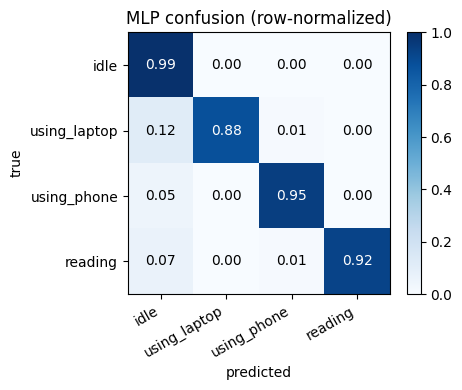

In [10]:
import matplotlib.pyplot as plt

row_sums = total_cm.sum(axis=1, keepdims=True)
norm_cm = total_cm / np.where(row_sums == 0, 1, row_sums)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(norm_cm, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(len(ACTION_NAMES)))
ax.set_yticks(range(len(ACTION_NAMES)))
ax.set_xticklabels(ACTION_NAMES, rotation=30, ha="right")
ax.set_yticklabels(ACTION_NAMES)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("MLP confusion (row-normalized)")

for i in range(len(ACTION_NAMES)):
    for j in range(len(ACTION_NAMES)):
        ax.text(j, i, f"{norm_cm[i, j]:.2f}", ha="center", va="center",
                color="white" if norm_cm[i, j] > 0.5 else "black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Save results

In [11]:
from src.classifier.common import results

results.save(
    runs_root / "results.json",
    model_name="mlp",
    action_names=ACTION_NAMES,
    fold_reports=fold_reports,
    fold_cms=fold_cms,
)
print(f"saved {runs_root / 'results.json'}")

saved C:\Research\Prototype\skeleton-based-hoi-recognition\runs\single_frame\results.json
